In [4]:
import pandas as pd
import numpy as np
import re

In [5]:
data = pd.read_json(
    "/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json",
    lines=True
)

print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (209527, 6)

Columns:
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

First 5 rows:


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [6]:
print("Number of unique categories:", data['category'].nunique())
print("\nCategory distribution:")
print(data['category'].value_counts())

Number of unique categories: 42

Category distribution:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144

In [7]:
categories = [
    'POLITICS',
    'WELLNESS',
    'ENTERTAINMENT',
    'TRAVEL',
    'BUSINESS'
]

df = data[data['category'].isin(categories)].copy()

print("Dataset shape:", df.shape)
print("\nCategory distribution:")
print(df['category'].value_counts())

Dataset shape: (86801, 6)

Category distribution:
category
POLITICS         35602
WELLNESS         17945
ENTERTAINMENT    17362
TRAVEL            9900
BUSINESS          5992
Name: count, dtype: int64


In [8]:
df = (
    df.groupby('category', group_keys=False)
      .apply(lambda x: x.sample(n=5000, random_state=42))
      .reset_index(drop=True)
)

print("Dataset shape:", df.shape)

print("\nCategory distribution:")
print(df['category'].value_counts())

Dataset shape: (25000, 6)

Category distribution:
category
BUSINESS         5000
ENTERTAINMENT    5000
POLITICS         5000
TRAVEL           5000
WELLNESS         5000
Name: count, dtype: int64


/tmp/ipykernel_58/2500551621.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=5000, random_state=42))


In [9]:
df['Article'] = df['headline'] + " " + df['short_description']

print(df[['headline', 'short_description', 'Article']].head())

                                            headline  \
0                  How to Manage Your Personal Brand   
1  It Looks Like Uber's Winning Its War With New ...   
2      The Progressive Promise of Today's Technology   
3   Don't Let These 5 Confusing Words Mar Your Image   
4        What You Don't Know About Overnight Success   

                                   short_description  \
0  Make no mistake: If you have a Facebook accoun...   
1                                  Grab the popcorn.   
2  A digital policy for the new century, tailored...   
3  Tom's an articulate physician, totally able to...   
4  I've been fighting this thing for 32 years. "O...   

                                             Article  
0  How to Manage Your Personal Brand Make no mist...  
1  It Looks Like Uber's Winning Its War With New ...  
2  The Progressive Promise of Today's Technology ...  
3  Don't Let These 5 Confusing Words Mar Your Ima...  
4  What You Don't Know About Overnight Success I'..

In [10]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
df['clean_article'] = df['Article'].apply(clean_text)
print(df[['Article', 'clean_article']].head())

                                             Article  \
0  How to Manage Your Personal Brand Make no mist...   
1  It Looks Like Uber's Winning Its War With New ...   
2  The Progressive Promise of Today's Technology ...   
3  Don't Let These 5 Confusing Words Mar Your Ima...   
4  What You Don't Know About Overnight Success I'...   

                                       clean_article  
0  how to manage your personal brand make no mist...  
1  it looks like uber's winning its war with new ...  
2  the progressive promise of today's technology ...  
3  don't let these 5 confusing words mar your ima...  
4  what you don't know about overnight success i'...  


In [12]:
X = df['clean_article']
y = df['category']
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample article:")
print(X.iloc[0])
print("\nSample category:")
print(y.iloc[0])

X shape: (25000,)
y shape: (25000,)

Sample article:
how to manage your personal brand make no mistake: if you have a facebook account, an instagram page, a twitter profile, you are a brand. every time you upload a photo, add a link, or post an update, you're putting into the world another idea of yourself and what you stand for.

Sample category:
BUSINESS


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded labels:", np.unique(y))
print("Category mapping:", dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
)))

Encoded labels: [0 1 2 3 4]
Category mapping: {'BUSINESS': np.int64(0), 'ENTERTAINMENT': np.int64(1), 'POLITICS': np.int64(2), 'TRAVEL': np.int64(3), 'WELLNESS': np.int64(4)}


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (20000,)
Testing data: (5000,)

Training labels: (20000,)
Testing labels: (5000,)


## Tokenization

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 38117


## Convert Text to Sequences

In [16]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("First training sequence:")
print(X_train_seq[0])

print("\nFirst test sequence:")
print(X_test_seq[0])

First training sequence:
[3011, 2910, 996, 1428, 6, 4, 673, 41, 124, 52, 441, 6, 121, 597, 494, 452, 10, 179, 1428, 1203, 2, 131, 27, 816, 1, 777, 3, 16, 64, 12, 9, 413, 5, 102, 15056, 27, 35, 1887, 13, 85, 17, 9, 7, 30, 121, 211, 13, 271, 377, 175, 1887]

First test sequence:
[155, 8888, 8483, 11799, 10191, 896, 11, 836, 1980, 13608, 1, 3004, 23092, 1491, 6, 1058, 25, 2066, 110, 2, 305, 44, 1, 11048]


## padding

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='pre'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='pre'
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (20000, 200)
Testing shape: (5000, 200)


In [19]:
import os
import urllib.request
import zipfile

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "/kaggle/working/glove.6B.zip"

urllib.request.urlretrieve(glove_url, glove_zip)

with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/glove")

print("GloVe downloaded and extracted!")

GloVe downloaded and extracted!


In [20]:
glove_path = "/kaggle/working/glove/glove.6B.100d.txt"

embeddings_index = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Number of GloVe words:", len(embeddings_index))

Number of GloVe words: 400000


In [21]:
embedding_matrix = np.zeros((vocab_size, 100))

for word, index in tokenizer.word_index.items():
    if word in embeddings_index:
        embedding_matrix[index] = embeddings_index[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (38117, 100)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding

model = Sequential()

model.add(Input(shape=(max_length,)))

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        weights=[embedding_matrix],
        trainable=False
    )
)

model.summary()

I0000 00:00:1789132096.666535      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789132096.670194      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     3,811,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811,700 (14.54 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,811,700 (14.54 MB)

In [23]:
from tensorflow.keras.layers import LSTM

model.add(LSTM(128))

In [24]:
from tensorflow.keras.layers import Dropout

model.add(Dropout(0.3))

In [25]:
from tensorflow.keras.layers import Dense

model.add(Dense(5, activation='softmax'))

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     3,811,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,929,593 (14.99 MB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 3,811,700 (14.54 MB)

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7396 - loss: 0.7409 - val_accuracy: 0.7905 - val_loss: 0.5987
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8162 - loss: 0.5340 - val_accuracy: 0.7985 - val_loss: 0.5529
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8374 - loss: 0.4710 - val_accuracy: 0.8270 - val_loss: 0.4975
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8505 - loss: 0.4295 - val_accuracy: 0.8310 - val_loss: 0.4812
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8633 - loss: 0.3955 - val_accuracy: 0.8400 - val_loss: 0.4723
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8688 - loss: 0.3705 - val_accuracy: 0.8405 - val_loss: 0.4466
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8818 - loss: 0.3441 - val_accuracy: 0.8445 - val_loss: 0.4671
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8886 - loss: 0.3160 - val_accu

In [30]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8472 - loss: 0.4340
Test Loss: 0.43403360247612
Test Accuracy: 0.8471999764442444


In [31]:
y_pred_prob = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test[:10])

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Predicted labels: [2 3 4 3 0 3 1 1 1 0]
Actual labels:    [2 3 4 3 1 2 2 1 1 4]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

               precision    recall  f1-score   support

     BUSINESS       0.77      0.80      0.79      1000
ENTERTAINMENT       0.87      0.86      0.86      1000
     POLITICS       0.84      0.84      0.84      1000
       TRAVEL       0.91      0.86      0.89      1000
     WELLNESS       0.85      0.87      0.86      1000

     accuracy                           0.85      5000
    macro avg       0.85      0.85      0.85      5000
 weighted avg       0.85      0.85      0.85      5000



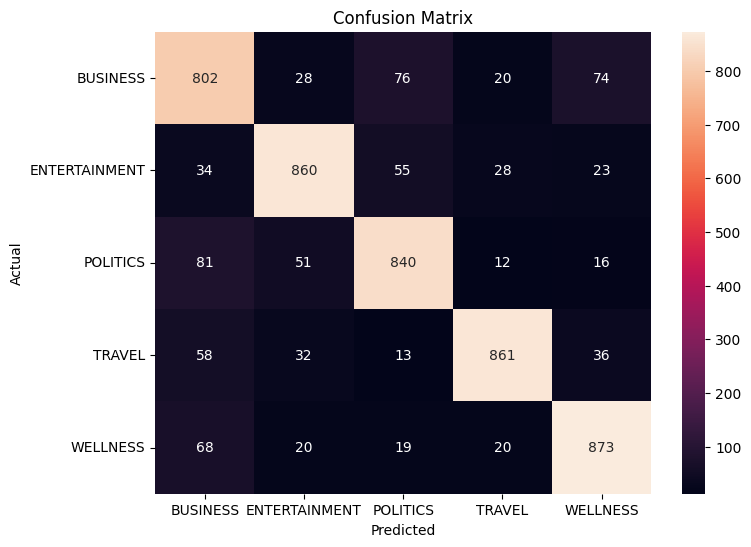

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

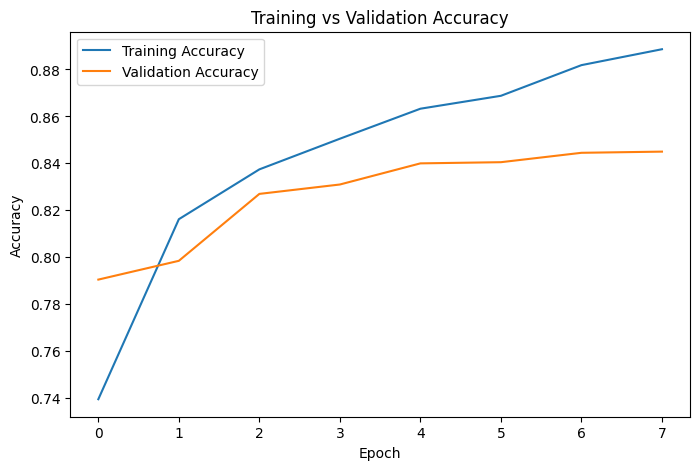

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

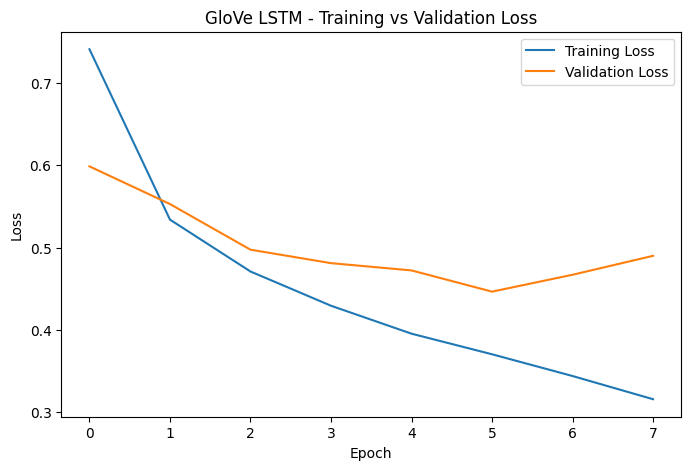

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GloVe LSTM - Training vs Validation Loss')
plt.legend()
plt.show()

In [36]:
new_article = """
Apple reported strong quarterly earnings as sales of its latest products
helped increase the company's revenue and profits.
"""
cleaned_article = clean_text(new_article)

new_seq = tokenizer.texts_to_sequences([cleaned_article])

new_pad = pad_sequences(
    new_seq,
    maxlen=max_length,
    padding='pre'
)

prediction_prob = model.predict(new_pad)

predicted_class = np.argmax(prediction_prob, axis=1)[0]

predicted_category = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("Predicted Category:", predicted_category)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Category: BUSINESS


In [37]:
for category, probability in zip(
    label_encoder.classes_,
    prediction_prob[0]
):
    print(f"{category}: {probability:.2%}")

BUSINESS: 99.35%
ENTERTAINMENT: 0.13%
POLITICS: 0.41%
TRAVEL: 0.02%
WELLNESS: 0.09%


In [45]:
model.save("/kaggle/working/news_classifier.h5")
print("Model saved successfully!")

Model saved successfully!


In [46]:
import os

print(os.path.exists("/kaggle/working/news_classifier.h5"))

True


In [39]:
import pickle

with open("/kaggle/working/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [40]:
with open("/kaggle/working/label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!
